# Classical vs Quantum Plays Nim

**COMP47950 Quantum Machine Learning — Implementation Notebook & Report**

## 1. Introduction

This project compares **classical** and **quantum** machine learning approaches on the game of **Nim** (normal play, $k = 3$ heaps, max heap size $M = 7$). The ML task is to predict whether a board position is **winning or losing** (Option B: state $\to$ win/loss classification based on Nim-sum), then use the prediction to select moves.

**Four pipelines:**
1. Classical ML baseline (SVM, Random Forest, Logistic Regression)
2. Quantum kernel SVM (isolates the value of the quantum feature map)
3. Simulated VQC (variational quantum classifier with angle and binary encoding)
4. Quantum device inference (IBM Quantum, inference-only)

**Central hypothesis (sample efficiency):** Nim-sum is an XOR/parity function over heap sizes — a structure that parity-aware quantum feature maps may exploit, allowing QML to reach comparable performance with fewer training samples than classical models.

**Secondary experiment (OOD generalisation):** Train on smaller board sizes ($M \leq 5$), test on larger unseen boards ($M = 6, 7$) to assess whether models learn the Nim-sum rule rather than memorising training data.

**Comparison metrics:** Balanced accuracy, Matthews correlation coefficient (MCC), win rate (vs random), sample efficiency (accuracy and win rate vs training set size), OOD accuracy, cost, speed, and interpretability.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qml_project import build_circuit, train_classifier
from qml_project.baselines import (
    prepare_features,
    engineer_parity_features,
    create_models,
    evaluate_model,
    evaluate_win_rate,
    run_classical_sweep,
    ClassicalResult,
    SweepResults,
    model_policy,
)
from qml_project.nim import (
    NimState,
    nim_sum,
    is_terminal,
    is_winning,
    legal_moves,
    apply_move,
    optimal_move,
    random_policy,
    optimal_policy,
    play_game,
    play_many,
    generate_dataset,
    prepare_experiment_data,
    class_balance_table,
    split_class_balance,
    majority_baseline_accuracy,
    compute_class_weights,
    iid_split,
    training_subsets,
    ood_split,
    normalise_states,
    enumerate_states,
    all_heap_permutations,
    augment_s3,
    augment_s3_moves,
    canonical_order,
    remap_move_to_original,
    count_canonical_states,
    augmentation_stats,
)

## 2. Nim Game and Data

*Supports: Input Transformation & Data Prep (10%)*

### 2.1 Game rules

**Nim** (normal play) is a two-player combinatorial game.  The state is a tuple of $k$ heap sizes $(h_1, h_2, \ldots, h_k)$ with $0 \leq h_i \leq M$.  On each turn the current player chooses one non-empty heap $i$ and removes between 1 and $h_i$ stones from it.  The game ends when all heaps are empty; under **normal play** the player who takes the last stone **wins**.

The game is completely solved by the **Nim-sum** — the bitwise XOR of all heap sizes:

$$n = h_1 \oplus h_2 \oplus \cdots \oplus h_k$$

| Nim-sum | Position | Meaning |
|---------|----------|---------|
| $n \neq 0$ | **Winning** | Current player can always force a win by moving to a state with $n = 0$ |
| $n = 0$ | **Losing** | Every legal move leaves $n \neq 0$, giving the opponent a winning position |

**Primary configuration:** $k = 3$ heaps, maximum heap size $M = 7$.  This yields $(M+1)^k - 1 = 511$ non-terminal states — small enough for exhaustive enumeration yet rich enough for meaningful ML experiments.

The game logic is implemented in `qml_project.nim.game` and supports arbitrary $k$ and $M$.

### 2.2 ML task

The ML task is **state $\to$ win/loss classification** (Option B): given a board position $(h_1, h_2, h_3)$, predict whether the current player is in a winning or losing position.  At play time, a winning prediction triggers the Nim-sum optimal move; a losing prediction triggers a random legal move.

This is simpler than full move prediction (Option A) and aligns with the supervisor's description of "a model that emits a binary response for a given board state."

In [3]:
rng = np.random.default_rng(42)

state: NimState = (3, 5, 2)
print(f"State:       {state}")
print(f"Nim-sum:     {nim_sum(state)}  (= {state[0]} ⊕ {state[1]} ⊕ {state[2]})")
print(f"Winning:     {is_winning(state)}")
print(f"Legal moves: {len(legal_moves(state))}  (sum of heap sizes)")

move = optimal_move(state, rng)
new_state = apply_move(state, move)
print(f"\nOptimal move: remove {move[1]} from heap {move[0]}")
print(f"New state:   {new_state}  →  Nim-sum = {nim_sum(new_state)}")

losing = (3, 5, 6)
print(f"\nLosing state: {losing}  →  Nim-sum = {nim_sum(losing)}, Winning = {is_winning(losing)}")

State:       (3, 5, 2)
Nim-sum:     4  (= 3 ⊕ 5 ⊕ 2)
Winning:     True
Legal moves: 10  (sum of heap sizes)

Optimal move: remove 4 from heap 1
New state:   (3, 1, 2)  →  Nim-sum = 0

Losing state: (3, 5, 6)  →  Nim-sum = 0, Winning = False


### 2.3 Playing Nim

`play_game` runs a full game between two policies; `play_many` aggregates win statistics over many games.  Below, the optimal (Nim-sum) policy plays 500 games against a random policy from the starting position $(7, 7, 7)$.  Since $7 \oplus 7 \oplus 7 = 7 \neq 0$, the first player (optimal) is in a winning position and should win every game.

In [4]:
stats = play_many(optimal_policy, random_policy, n_games=500, seed=42)
print(f"Optimal (player A) vs Random (player B)  —  500 games from (7,7,7)")
print(f"  Player A wins: {stats['wins_a']}  ({stats['win_rate_a']:.0%})")
print(f"  Player B wins: {stats['wins_b']}  ({stats['win_rate_b']:.0%})")

rec = stats["games"][0]
print(f"\nExample game ({len(rec)} moves):")
for i, (s, m) in enumerate(zip(rec.states[:-1], rec.moves)):
    player = "A" if i % 2 == 0 else "B"
    print(f"  {s}  →  Player {player} removes {m[1]} from heap {m[0]}")
print(f"  {rec.states[-1]}  →  Player {'A' if rec.winner == 0 else 'B'} wins")

Optimal (player A) vs Random (player B)  —  500 games from (7,7,7)
  Player A wins: 500  (100%)
  Player B wins: 0  (0%)

Example game (7 moves):
  (7, 7, 7)  →  Player A removes 7 from heap 0
  (0, 7, 7)  →  Player B removes 4 from heap 2
  (0, 7, 3)  →  Player A removes 4 from heap 1
  (0, 3, 3)  →  Player B removes 1 from heap 2
  (0, 3, 2)  →  Player A removes 1 from heap 1
  (0, 2, 2)  →  Player B removes 2 from heap 1
  (0, 0, 2)  →  Player A removes 2 from heap 2
  (0, 0, 0)  →  Player A wins


### 2.4 Data generation and class balance

We exhaustively enumerate all non-terminal states for $k = 3$ heaps, $M = 7$, yielding $(M+1)^k - 1 = 511$ states.  Each state is labelled with:

- **Win/loss (Option B):** winning ($\text{Nim-sum} \neq 0$) or losing ($\text{Nim-sum} = 0$).
- **Optimal move index (Option A):** a flat index encoding the move $(h, a) \mapsto h \cdot M + (a - 1)$, giving $k \times M = 21$ possible move classes.

Data generation is implemented in `qml_project.nim.data`.

#### Class imbalance analysis

For $k = 3$ heaps the number of losing positions (Nim-sum $= 0$) is exactly $(M+1)^2 - 1$.  Each losing position is determined by choosing $h_1$ and $h_2$ freely, then setting $h_3 = h_1 \oplus h_2$ (the unique value that zeros the Nim-sum); the $-1$ excludes the terminal state $(0, 0, 0)$.  At $M = 7$ this gives **63 losing vs 448 winning states (12.3% minority class)**.

A naive classifier that always predicts "winning" achieves **87.7% raw accuracy** — a misleadingly high number.  This majority-class baseline makes raw accuracy unsuitable as the primary evaluation metric.

The table and bar chart below show how the imbalance varies with $M$.  The minority fraction decreases with $M$ because the number of winning states grows as $(M+1)^3 - (M+1)^2$ while losing states grow only as $(M+1)^2 - 1$.

Total non-terminal states: 511
  Winning: 448  Losing: 63
  Move classes (Option A): 21

Majority-class (always predict 'winning') baseline accuracy: 87.7%

Class balance by M (k = 3 heaps):


,M,total,winning,losing,pct_losing
0,1,7,4,3,42.9
1,2,26,20,6,23.1
2,3,63,48,15,23.8
3,4,124,106,18,14.5
4,5,215,188,27,12.6
5,6,342,300,42,12.3
6,7,511,448,63,12.3


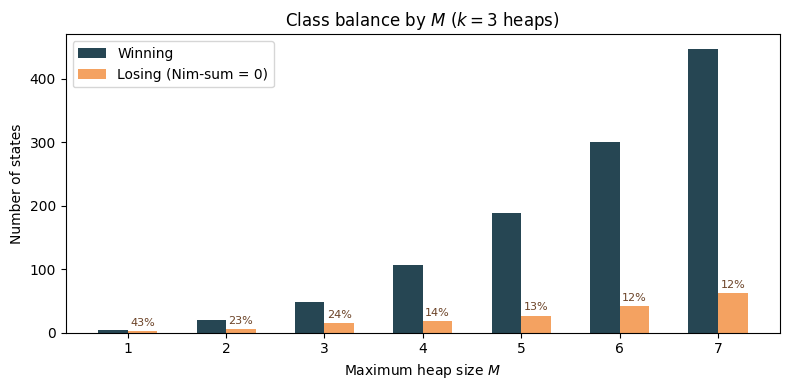

In [5]:
dataset = generate_dataset(k=3, M=7, random_state=42)
print(f"Total non-terminal states: {len(dataset)}")
print(f"  Winning: {dataset.is_winning.sum()}  Losing: {(1 - dataset.is_winning).sum()}")
print(f"  Move classes (Option A): {dataset.n_classes_move}")

maj_acc = majority_baseline_accuracy(dataset.is_winning)
print(f"\nMajority-class (always predict 'winning') baseline accuracy: {maj_acc:.1%}")

balance = class_balance_table(M_values=range(1, 8), k=3)
print("\nClass balance by M (k = 3 heaps):")
display(balance)

fig, ax = plt.subplots(figsize=(8, 4))
x = balance["M"]
ax.bar(x - 0.15, balance["winning"], width=0.3, label="Winning", color="#264653")
ax.bar(x + 0.15, balance["losing"], width=0.3, label="Losing (Nim-sum = 0)", color="#f4a261")
for i, row in balance.iterrows():
    ax.text(row["M"] + 0.15, row["losing"] + 5, f"{row['pct_losing']:.0f}%",
            ha="center", va="bottom", fontsize=8, color="#6b4226")
ax.set_xlabel("Maximum heap size $M$")
ax.set_ylabel("Number of states")
ax.set_title("Class balance by $M$ ($k = 3$ heaps)")
ax.legend()
ax.set_xticks(range(1, 8))
plt.tight_layout()
plt.show()

The heatmap below fixes $h_3 = 0$ and colours the $(h_1, h_2)$ plane by win (blue) vs loss (orange, Nim-sum $= 0$).  Losing positions lie along $h_1 = h_2$ (since $h_1 \oplus h_2 \oplus 0 = 0 \iff h_1 = h_2$), illustrating the XOR decision boundary that the ML models must learn.

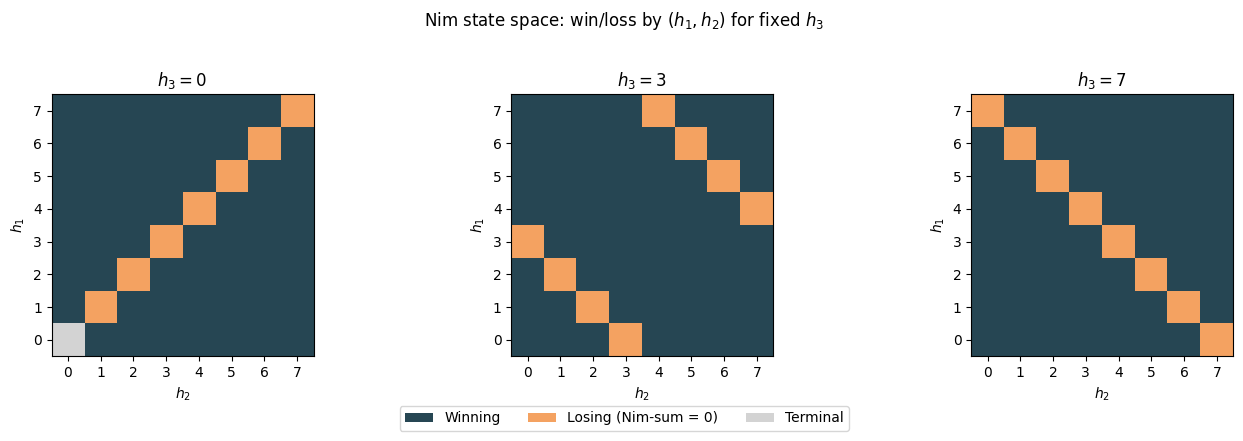

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, h3 in zip(axes, [0, 3, 7]):
    grid = np.zeros((8, 8), dtype=int)
    for h1 in range(8):
        for h2 in range(8):
            if (h1, h2, h3) == (0, 0, 0) and h3 == 0:
                grid[h1, h2] = -1
            else:
                grid[h1, h2] = 1 if (h1 ^ h2 ^ h3) != 0 else 0
    cmap = plt.cm.colors.ListedColormap(["lightgrey", "#f4a261", "#264653"])
    im = ax.imshow(grid, origin="lower", cmap=cmap, vmin=-1, vmax=1)
    ax.set_xlabel("$h_2$")
    ax.set_ylabel("$h_1$")
    ax.set_title(f"$h_3 = {h3}$")
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#264653", label="Winning"),
                   Patch(facecolor="#f4a261", label="Losing (Nim-sum = 0)"),
                   Patch(facecolor="lightgrey", label="Terminal")]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Nim state space: win/loss by $(h_1, h_2)$ for fixed $h_3$", y=1.02)
plt.tight_layout()
plt.show()

#### Class balance across data splits

The table below shows class balance for every partition used in the project: IID train/val/test, each training-size subset, and both OOD partitions.  Stratified splitting preserves the ~88/12 ratio in all partitions.  The final column shows the majority-class baseline accuracy for that split — the floor that any model must beat to demonstrate learning.

At the smallest subset (50 samples) only **6 losing examples** are available; minority-class performance estimates at this size are inherently noisy and should be interpreted with caution.

#### Imbalance handling strategy

Three complementary strategies address the class imbalance:

1. **Balanced accuracy and MCC as primary metrics.**  Raw accuracy is inflated by the majority class; balanced accuracy (mean of per-class recall) and MCC (Matthews correlation coefficient) are insensitive to class priors and provide a fairer comparison across pipelines and training sizes.
2. **Class-weighted loss functions.**  Both classical models (`class_weight='balanced'` in sklearn) and VQC loss functions use inverse-frequency weights, so each minority-class example contributes proportionally more to the training signal.  The weights are $w_k = \tfrac{n}{2 \cdot n_k}$ for class $k$, yielding higher weight for the rare losing class.
3. **Stratified sampling.**  All IID splits, training-size subsets, and OOD-within-train sampling use stratification on the win/loss label, ensuring every partition reflects the population class ratio.

In [7]:
iid = iid_split(dataset, random_state=42)
subsets = training_subsets(iid.X_train, iid.y_train, sizes=[50, 100, 200],
                          random_state=42)
ood = ood_split(k=3, M_train=5, M_test=7, random_state=42)

named_splits = {
    "IID Train": iid.y_train,
    "IID Val": iid.y_val,
    "IID Test": iid.y_test,
    "Subset 50": subsets[50].y,
    "Subset 100": subsets[100].y,
    "Subset 200": subsets[200].y,
    "OOD Train (M ≤ 5)": ood.y_train,
    "OOD Test (M > 5)": ood.y_test,
}

balance_splits = split_class_balance(named_splits)
print("Class balance across all data splits:")
display(balance_splits)

weights = compute_class_weights(iid.y_train)
print(f"\nClass weights (IID training set): losing (0) = {weights[0]:.2f}, winning (1) = {weights[1]:.2f}")
print(f"  → Losing examples receive {weights[0]/weights[1]:.1f}× the weight of winning examples.")

Class balance across all data splits:


,split,n,winning,losing,pct_losing,majority_baseline
0,IID Train,357,313,44,12.3,87.7
1,IID Val,77,68,9,11.7,88.3
2,IID Test,77,67,10,13.0,87.0
3,Subset 50,50,44,6,12.0,88.0
4,Subset 100,100,88,12,12.0,88.0
5,Subset 200,200,175,25,12.5,87.5
6,OOD Train (M ≤ 5),215,188,27,12.6,87.4
7,OOD Test (M > 5),296,260,36,12.2,87.8



Class weights (IID training set): losing (0) = 4.06, winning (1) = 0.57
  → Losing examples receive 7.1× the weight of winning examples.


### 2.5 IID splits and training-size subsets

**IID regime (development and sanity check):** a stratified 70 / 15 / 15 train / validation / test split on the $M = 7$ states.  Stratification is on the binary win/loss label so every partition preserves the ~88 / 12 class ratio.

**Sample-efficiency subsets:** stratified sub-samples of the training set at sizes 50, 100, and 200 (the full training set of ~357 is always included).  Each pipeline is trained on every subset with 10+ seeds to produce the central **accuracy vs training size** comparison.

All splits use `random_state=42`.

In [8]:
print(f"IID split sizes (M = 7, stratified by win/loss):")
print(f"  Train: {len(iid.y_train)}   Val: {len(iid.y_val)}   Test: {len(iid.y_test)}")
print(f"  Total: {len(iid.y_train) + len(iid.y_val) + len(iid.y_test)}")

IID split sizes (M = 7, stratified by win/loss):
  Train: 357   Val: 77   Test: 77
  Total: 511


In [9]:
print("Training-size subsets for sample-efficiency sweep:")
for key in [50, 100, 200, "full"]:
    s = subsets[key]
    print(f"  {str(key):>4s}: {s.size} samples")

Training-size subsets for sample-efficiency sweep:
    50: 50 samples
   100: 100 samples
   200: 200 samples
  full: 357 samples


### 2.6 OOD regime

**Out-of-distribution evaluation (secondary experiment):** train on all non-terminal states with heaps $\leq M_{\text{train}} = 5$ (215 states) and test on states with at least one heap $> 5$ (296 states with heaps $\leq 7$).  This tests whether models learn the Nim-sum rule rather than memorising the training distribution — addressing supervisor feedback on test/train contamination.

Feature normalisation always divides by a fixed $M_{\max} = 7$ so that the $[0, 1]$ feature range is consistent between IID and OOD regimes.

In [10]:
print(f"OOD split: train on M ≤ {ood.M_train}, test on M > {ood.M_train} (M ≤ {ood.M_test})")
print(f"  Train: {len(ood.y_train)} states   Test: {len(ood.y_test)} states")

OOD split: train on M ≤ 5, test on M > 5 (M ≤ 7)
  Train: 215 states   Test: 296 states


### 2.7 Feature normalisation

Classical features are the raw heap sizes normalised by a fixed $M_{\max} = 7$: $x_i = h_i / M_{\max} \in [0, 1]$.  This global constant ensures the feature range is identical across IID and OOD regimes (training on $M \leq 5$ and testing on $M \leq 7$ use the same denominator).  Quantum angle encoding similarly uses $\theta_i = h_i \cdot \pi / M_{\max}$ (§4).

In [11]:
X_norm = normalise_states(iid.X_train, M_max=7)
print(f"Normalised training features: shape {X_norm.shape}, "
      f"range [{X_norm.min():.3f}, {X_norm.max():.3f}]")
print(f"Example: heaps {tuple(int(x) for x in iid.X_train[0])} "
      f"→ features {tuple(round(float(x), 3) for x in X_norm[0])}")

Normalised training features: shape (357, 3), range [0.000, 1.000]
Example: heaps (7, 7, 5) → features (1.0, 1.0, 0.714)


### 2.8 Heap permutation symmetry ($S_3$)

Nim with $k = 3$ heaps has **$S_3$ permutation symmetry**: the states $(3, 5, 2)$, $(5, 2, 3)$, $(2, 3, 5)$, and all other permutations are **strategically identical** — the Nim-sum $h_1 \oplus h_2 \oplus h_3$ is invariant under heap reordering, so win/loss status and optimal strategy are unchanged. Any optimal move on one permutation maps to an optimal move on the corresponding heap in another permutation.

This symmetry is directly relevant to the **sample efficiency hypothesis**: if a model must independently learn that $(3, 5, 2)$ and $(5, 2, 3)$ are equivalent, it needs more data than one that exploits this equivalence structurally. We implement three approaches:

1. **Data augmentation** — for each training example $(h_1, h_2, h_3)$, add all distinct permutations (up to $6\times$ expansion). Straightforward; applies equally to classical and QML pipelines.
2. **Canonical ordering** — sort heaps ascending ($h_1 \leq h_2 \leq h_3$) before encoding. This collapses equivalent states into a single representative, reducing the effective state space.
3. **Equivariant circuit design** (QML only) — constrain the VQC architecture to be permutation-invariant via parameter tying or symmetric entanglement patterns (deferred to §5).

The controlled experiment (§8) compares performance **with and without** symmetry exploitation at each training size to test whether inductive bias can substitute for data.

In [12]:
# --- Example: S_3 symmetry of a single state ---
example = np.array([3, 5, 2])
perms = all_heap_permutations(example)
print(f"State {tuple(int(x) for x in example)} has {len(perms)} unique permutations:")
for p in perms:
    print(f"  {p}  Nim-sum = {nim_sum(p)}")

# --- Canonical ordering collapses 511 states → fewer equivalence classes ---
n_canonical = count_canonical_states(k=3, M=7)
print(f"\nCanonical states (k=3, M=7): {n_canonical} "
      f"(collapsed from {len(dataset)} raw states, "
      f"reduction factor {len(dataset)/n_canonical:.1f}×)")

# Show canonical counts across M values
print("\nCanonical state counts by M:")
for M_val in [3, 4, 5, 6, 7]:
    raw = len(enumerate_states(3, M_val))
    canon = count_canonical_states(3, M_val)
    print(f"  M={M_val}: {raw:>4} raw → {canon:>4} canonical "
          f"(reduction {raw/canon:.1f}×)")

State (3, 5, 2) has 6 unique permutations:
  (2, 3, 5)  Nim-sum = 4
  (2, 5, 3)  Nim-sum = 4
  (3, 2, 5)  Nim-sum = 4
  (3, 5, 2)  Nim-sum = 4
  (5, 2, 3)  Nim-sum = 4
  (5, 3, 2)  Nim-sum = 4

Canonical states (k=3, M=7): 119 (collapsed from 511 raw states, reduction factor 4.3×)

Canonical state counts by M:
  M=3:   63 raw →   19 canonical (reduction 3.3×)
  M=4:  124 raw →   34 canonical (reduction 3.6×)
  M=5:  215 raw →   55 canonical (reduction 3.9×)
  M=6:  342 raw →   83 canonical (reduction 4.1×)
  M=7:  511 raw →  119 canonical (reduction 4.3×)


In [13]:
# --- Data augmentation: expansion at each training size ---
print("Augmentation expansion by training-size subset:\n")
print(f"{'Subset':>8}  {'Original':>8}  {'Augmented':>9}  {'No-dedup':>8}  {'Factor':>7}")
print("-" * 52)

for key in [50, 100, 200, "full"]:
    sub = subsets[key]
    X_aug, y_aug = augment_s3(sub.X, sub.y, deduplicate=True)
    X_aug_nd, _ = augment_s3(sub.X, sub.y, deduplicate=False)
    label = str(key) if isinstance(key, int) else f"full ({sub.size})"
    print(f"{label:>8}  {sub.size:>8}  {len(X_aug):>9}  {X_aug_nd.shape[0]:>8}  "
          f"{len(X_aug)/sub.size:>6.2f}×")

# --- Canonical ordering of the training set ---
X_canon, sort_perms = canonical_order(iid.X_train)
n_unique_canon = len(np.unique(X_canon, axis=0))
print(f"\nIID training set: {len(iid.X_train)} rows → "
      f"{n_unique_canon} unique canonical forms")

Augmentation expansion by training-size subset:

  Subset  Original  Augmented  No-dedup   Factor
----------------------------------------------------
      50        50        191       300    3.82×
     100       100        299       600    2.99×
     200       200        464      1200    2.32×
full (357)       357        497      2142    1.39×

IID training set: 357 rows → 114 unique canonical forms


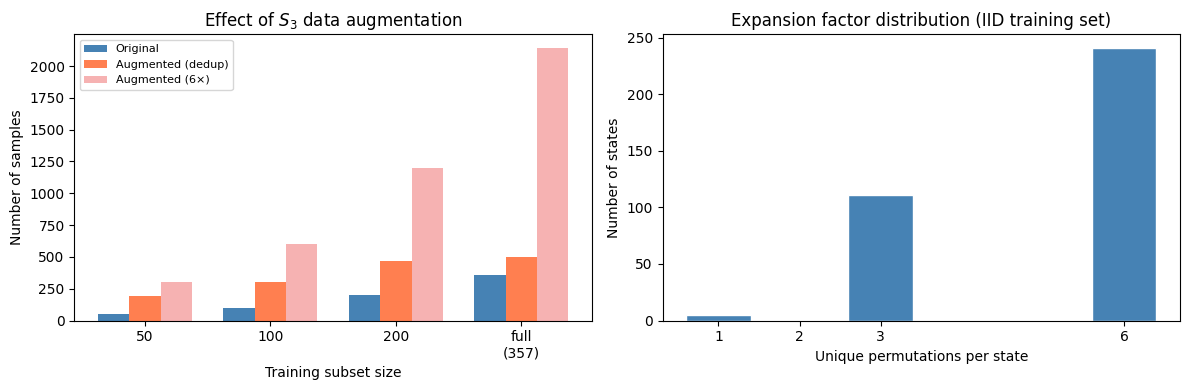

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: augmented size vs original size for each subset
subset_keys = [50, 100, 200, "full"]
orig_sizes, aug_sizes, aug_nd_sizes = [], [], []
for key in subset_keys:
    sub = subsets[key]
    X_a, _ = augment_s3(sub.X, sub.y, deduplicate=True)
    X_and, _ = augment_s3(sub.X, sub.y, deduplicate=False)
    orig_sizes.append(sub.size)
    aug_sizes.append(len(X_a))
    aug_nd_sizes.append(len(X_and))

x_pos = np.arange(len(subset_keys))
w = 0.25
axes[0].bar(x_pos - w, orig_sizes, w, label="Original", color="steelblue")
axes[0].bar(x_pos, aug_sizes, w, label="Augmented (dedup)", color="coral")
axes[0].bar(x_pos + w, aug_nd_sizes, w, label="Augmented (6×)", color="lightcoral", alpha=0.6)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(k) if isinstance(k, int) else f"full\n({subsets[k].size})" for k in subset_keys])
axes[0].set_xlabel("Training subset size")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Effect of $S_3$ data augmentation")
axes[0].legend(fontsize=8)

# Right: per-state expansion factor distribution (full training set)
stats = augmentation_stats(iid.X_train)
counts = stats["n_unique_perms"].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Unique permutations per state")
axes[1].set_ylabel("Number of states")
axes[1].set_title("Expansion factor distribution (IID training set)")
axes[1].set_xticks([1, 2, 3, 6])

plt.tight_layout()
plt.show()

**Observations:**

- The 511 non-terminal states collapse to just **119 canonical equivalence classes** under $S_3$ — a $4.3\times$ reduction. States with all-distinct heaps (expansion factor 6) dominate; states with two or three equal heaps contribute fewer unique permutations.
- **Data augmentation benefit scales inversely with training set size.** At 50 samples, augmentation yields a substantial expansion (most of the 6 unique permutations are genuinely new). At full training size (357), deduplication collapses much of the expansion because the IID split already covers most permutations.
- **Canonical ordering** reduces the input space by a fixed $4.3\times$ regardless of training size, but discards heap identity (which heap to take from). For **Option B** (win/loss), this is a clean simplification. For **Option A** (move prediction), the sort permutation must be stored to remap predicted moves back to the original heap ordering (`remap_move_to_original`).

Both approaches will be used as controlled variables in the sample-efficiency experiment (§8), comparing raw vs augmented vs canonical at each training size for both classical and QML pipelines.

## 3. Classical ML Baseline

*Supports: Evaluation & Discussion (15%); baseline for Midterm (10%)*

We train three classifiers — **SVM (RBF kernel)**, **Random Forest**, and **Logistic Regression** — on the win/loss classification task (Option B). All models use `class_weight='balanced'` to address the ~88/12 class imbalance (§2.4).

**Feature variants:**
- **Raw:** normalised heap sizes $(h_i / M_{\max})$ — 3 features.
- **Parity:** raw features augmented with heap parities ($h_i \bmod 2$), pairwise XOR values ($h_i \oplus h_j$ normalised), and column-wise bit parities (individual bits of the Nim-sum) — 12 features total.

**Symmetry variants:** Each configuration is tested both **without** and **with** $S_3$ data augmentation (§2.8).

**Sample efficiency:** Each configuration is trained on subsets of size 50, 100, 200, and full (357) with **10 seeds** per configuration. Each seed produces a different stratified subsample, so variance reflects both data sampling and (for Random Forest) model randomness.

**Evaluation:** Balanced accuracy (primary), MCC, F1, confusion matrices, and win rate vs random (500 games per configuration).

### 3.1 Feature engineering preview

Before running the full sweep, we inspect the two feature sets on a single example.

In [15]:
example_states = np.array([[3, 5, 2], [4, 4, 0], [7, 7, 7]])
raw = prepare_features(example_states, "raw", M=7)
par = prepare_features(example_states, "parity", M=7)

feature_names_raw = ["h0/M", "h1/M", "h2/M"]
feature_names_par = (
    feature_names_raw
    + ["h0%2", "h1%2", "h2%2"]
    + ["h0^h1/M", "h0^h2/M", "h1^h2/M"]
    + ["bit0_par", "bit1_par", "bit2_par"]
)

print("Raw features (3):")
_idx = [str(tuple(int(x) for x in s)) for s in example_states]
print(pd.DataFrame(raw, columns=feature_names_raw, index=_idx).round(3))
print(f"\nParity features ({par.shape[1]}):")
print(pd.DataFrame(par, columns=feature_names_par, index=_idx).round(3))

Raw features (3):
            h0/M   h1/M   h2/M
(3, 5, 2)  0.429  0.714  0.286
(4, 4, 0)  0.571  0.571  0.000
(7, 7, 7)  1.000  1.000  1.000

Parity features (12):
            h0/M   h1/M   h2/M  h0%2  h1%2  h2%2  h0^h1/M  h0^h2/M  h1^h2/M  \
(3, 5, 2)  0.429  0.714  0.286   1.0   1.0   0.0    0.857    0.143    1.000   
(4, 4, 0)  0.571  0.571  0.000   0.0   0.0   0.0    0.000    0.571    0.571   
(7, 7, 7)  1.000  1.000  1.000   1.0   1.0   1.0    0.000    0.000    0.000   

           bit0_par  bit1_par  bit2_par  
(3, 5, 2)       0.0       0.0       1.0  
(4, 4, 0)       0.0       0.0       0.0  
(7, 7, 7)       1.0       1.0       1.0  


### 3.2 IID baseline sweep

We run the full sweep over 3 models $\times$ 2 feature sets $\times$ 2 symmetry variants $\times$ 4 training sizes $\times$ 10 seeds = **480 configurations** with win-rate evaluation (200 games each).

In [16]:
iid_sweep = run_classical_sweep(
    iid.X_train, iid.y_train,
    iid.X_test, iid.y_test,
    model_names=["SVM (RBF)", "Random Forest", "Logistic Regression"],
    feature_sets=["raw", "parity"],
    symmetry_variants=["none", "augmented"],
    train_sizes=[50, 100, 200, "full"],
    seeds=list(range(10)),
    M=7,
    regime="iid",
    compute_win_rate=True,
    n_games_win_rate=200,
    mlflow_experiment="classical-baselines-iid",
    verbose=True,
)

  [20/480] runs complete
  [40/480] runs complete
  [60/480] runs complete
  [80/480] runs complete
  [100/480] runs complete
  [120/480] runs complete
  [140/480] runs complete
  [160/480] runs complete
  [180/480] runs complete
  [200/480] runs complete
  [220/480] runs complete
  [240/480] runs complete
  [260/480] runs complete
  [280/480] runs complete
  [300/480] runs complete
  [320/480] runs complete
  [340/480] runs complete
  [360/480] runs complete
  [380/480] runs complete
  [400/480] runs complete
  [420/480] runs complete
  [440/480] runs complete
  [460/480] runs complete
  [480/480] runs complete
  Sweep complete: 480 runs.


### 3.3 Summary metrics (IID)

Mean $\pm$ std over 10 seeds for balanced accuracy, MCC, and win rate at each training size.

In [17]:
iid_df = iid_sweep.to_dataframe()
iid_summary = iid_sweep.summary()

display_cols = [
    "model", "feature_set", "symmetry", "train_size",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "mcc_std",
    "win_rate_mean", "win_rate_std",
]
summary_display = iid_summary[display_cols].copy()
for col in ["balanced_accuracy_mean", "balanced_accuracy_std", "mcc_mean", "mcc_std",
             "win_rate_mean", "win_rate_std"]:
    summary_display[col] = summary_display[col].round(3)

pd.set_option("display.max_rows", None)
summary_display

,model,feature_set,symmetry,train_size,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,win_rate_mean,win_rate_std
0,Logistic Regression,parity,augmented,50,0.987,0.025,0.930,0.126,0.980,0.036
1,Logistic Regression,parity,augmented,100,1.000,0.000,1.000,0.000,1.000,0.000
2,Logistic Regression,parity,augmented,200,1.000,0.000,1.000,0.000,1.000,0.000
3,Logistic Regression,parity,augmented,357,1.000,0.000,1.000,0.000,1.000,0.000
4,Logistic Regression,parity,none,50,0.959,0.040,0.842,0.054,0.897,0.143
5,Logistic Regression,parity,none,100,0.992,0.015,0.951,0.086,0.989,0.025
6,Logistic Regression,parity,none,200,1.000,0.000,1.000,0.000,1.000,0.000
7,Logistic Regression,parity,none,357,1.000,0.000,1.000,0.000,1.000,0.000
8,Logistic Regression,raw,augmented,50,0.542,0.033,0.058,0.046,0.496,0.036
9,Logistic Regression,raw,augmented,100,0.499,0.026,-0.001,0.036,0.493,0.038


### 3.4 Sample-efficiency curves

Balanced accuracy and win rate vs training set size — the classical half of the project's central comparison figure.

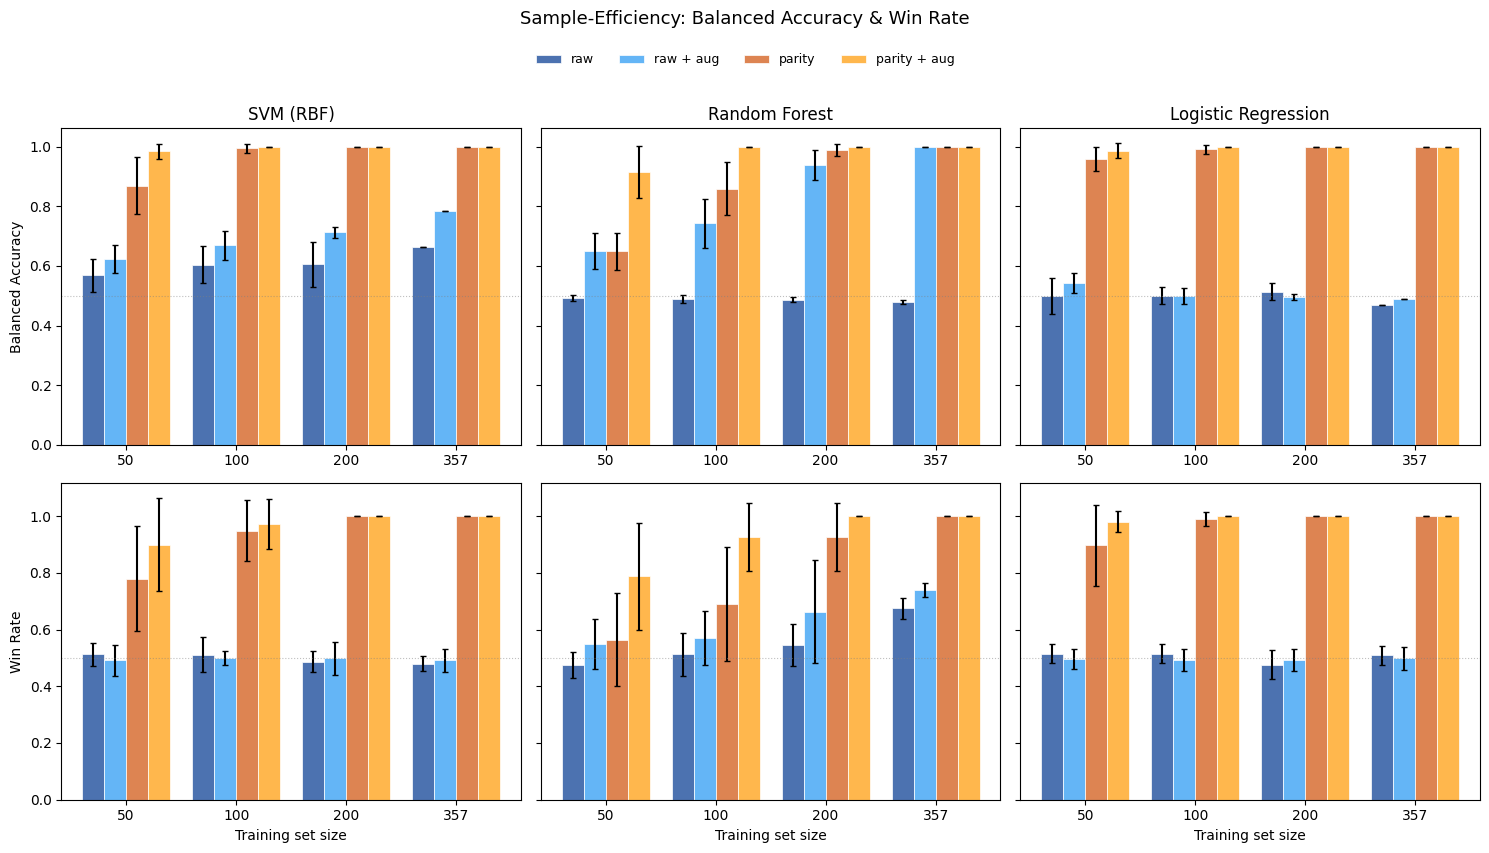

In [18]:
models = ["SVM (RBF)", "Random Forest", "Logistic Regression"]
configs = [
    ("raw", "none"),
    ("raw", "augmented"),
    ("parity", "none"),
    ("parity", "augmented"),
]
config_labels = ["raw", "raw + aug", "parity", "parity + aug"]
config_colors = ["#4c72b0", "#64b5f6", "#dd8452", "#ffb74d"]
metrics = [
    ("balanced_accuracy", "Balanced Accuracy"),
    ("win_rate", "Win Rate"),
]

train_sizes = sorted(iid_df["train_size"].unique())
n_sizes = len(train_sizes)
n_bars = len(configs)
bar_width = 0.8 / n_bars

fig, axes = plt.subplots(len(metrics), len(models), figsize=(15, 8),
                         sharey="row")

for row, (metric, metric_label) in enumerate(metrics):
    for col, model in enumerate(models):
        ax = axes[row, col]
        for b, ((fs, sym), label, color) in enumerate(
            zip(configs, config_labels, config_colors)
        ):
            mask = (
                (iid_df["model"] == model)
                & (iid_df["feature_set"] == fs)
                & (iid_df["symmetry"] == sym)
            )
            grouped = iid_df[mask].groupby("train_size")[metric].agg(["mean", "std"])
            grouped = grouped.reindex(train_sizes)
            x = np.arange(n_sizes) + b * bar_width
            ax.bar(
                x, grouped["mean"], bar_width,
                yerr=grouped["std"], label=label if (row == 0 and col == 0) else None,
                color=color, capsize=2, edgecolor="white", linewidth=0.5,
            )
        ax.set_xticks(np.arange(n_sizes) + bar_width * (n_bars - 1) / 2)
        ax.set_xticklabels(train_sizes)
        ax.axhline(0.5, color="grey", linestyle=":", alpha=0.5, linewidth=0.8)
        if row == len(metrics) - 1:
            ax.set_xlabel("Training set size")
        if col == 0:
            ax.set_ylabel(metric_label)
        if row == 0:
            ax.set_title(model)

fig.legend(
    *axes[0, 0].get_legend_handles_labels(),
    loc="upper center", ncol=n_bars, frameon=False,
    bbox_to_anchor=(0.5, 1.02), fontsize=9,
)
fig.suptitle("Sample-Efficiency: Balanced Accuracy & Win Rate", y=1.06, fontsize=13)
plt.tight_layout()
plt.show()

### 3.5 Confusion matrices (full training set, seed 0)

Confusion matrices for all three models with raw and parity features at full training size.

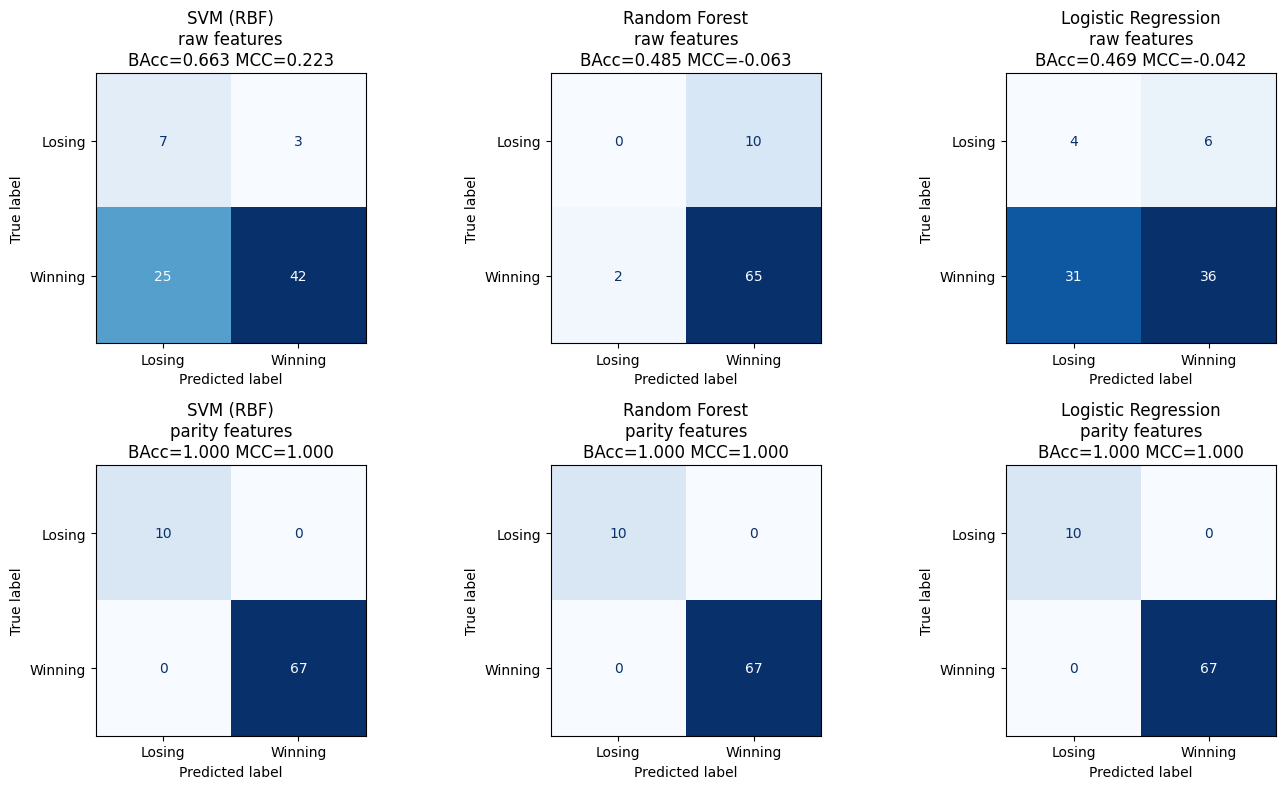

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

model_names_disp = ["SVM (RBF)", "Random Forest", "Logistic Regression"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, model_name in enumerate(model_names_disp):
    for row, fs in enumerate(["raw", "parity"]):
        ax = axes[row, col]
        # Pick seed=0, full training, no symmetry
        match = [
            r for r in iid_sweep.results
            if r.model_name == model_name
            and r.feature_set == fs
            and r.symmetry == "none"
            and r.train_size == len(iid.X_train)
            and r.seed == 0
        ]
        if match:
            r = match[0]
            ConfusionMatrixDisplay(r.cm, display_labels=["Losing", "Winning"]).plot(
                ax=ax, colorbar=False, cmap="Blues",
            )
            ax.set_title(f"{model_name}\n{fs} features\nBAcc={r.balanced_accuracy:.3f} MCC={r.mcc:.3f}")
        else:
            ax.set_visible(False)

plt.tight_layout()
plt.show()

### 3.6 OOD evaluation

Train on $M \leq 5$ states, test on $M > 5$ states (heaps $\leq 7$). This establishes the classical OOD baseline for comparison with QML.

In [20]:
ood_sweep = run_classical_sweep(
    ood.X_train, ood.y_train,
    ood.X_test, ood.y_test,
    model_names=["SVM (RBF)", "Random Forest", "Logistic Regression"],
    feature_sets=["raw", "parity"],
    symmetry_variants=["none", "augmented"],
    train_sizes=["full"],
    seeds=list(range(10)),
    M=7,
    regime="ood",
    compute_win_rate=False,
    mlflow_experiment="classical-baselines-ood",
    verbose=True,
)

ood_summary = ood_sweep.summary()
ood_display = ood_summary[[
    "model", "feature_set", "symmetry",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "mcc_std",
]].copy()
for col in ood_display.columns[3:]:
    ood_display[col] = ood_display[col].round(3)

print("OOD results (train M≤5, test M>5):")
ood_display

  [20/120] runs complete
  [40/120] runs complete
  [60/120] runs complete
  [80/120] runs complete
  [100/120] runs complete
  [120/120] runs complete
  Sweep complete: 120 runs.
OOD results (train M≤5, test M>5):


,model,feature_set,symmetry,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std
0,Logistic Regression,parity,augmented,1.000,0.000,1.000,0.000
1,Logistic Regression,parity,none,1.000,0.000,1.000,0.000
2,Logistic Regression,raw,augmented,0.477,0.000,-0.076,0.000
3,Logistic Regression,raw,none,0.477,0.000,-0.076,0.000
4,Random Forest,parity,augmented,0.757,0.059,0.690,0.089
5,Random Forest,parity,none,0.738,0.064,0.661,0.095
6,Random Forest,raw,augmented,0.526,0.000,0.051,0.000
7,Random Forest,raw,none,0.526,0.000,0.051,0.000
8,SVM (RBF),parity,augmented,1.000,0.000,1.000,0.000
9,SVM (RBF),parity,none,1.000,0.000,1.000,0.000


### 3.7 Key observations

**Raw features (normalised heap sizes only):**
- Without augmentation, SVM (RBF) is the strongest classifier on raw features by balanced accuracy (~0.66 at full training size), while Random Forest (~0.48) and Logistic Regression (~0.47) hover near the majority baseline. This confirms that the Nim-sum decision boundary is difficult to learn from heap sizes alone.
- With $S_3$ augmentation, Random Forest shows a dramatic improvement, reaching **perfect** balanced accuracy (1.000) at full training size — far surpassing the other models. SVM (RBF) also improves substantially (~0.78 augmented vs ~0.66 unaugmented at full size), while Logistic Regression sees negligible benefit.
- Win rates on raw features do **not** consistently track balanced accuracy. SVM (RBF) achieves ~0.66 balanced accuracy but only ~0.48 win rate; conversely, Random Forest without augmentation has ~0.48 balanced accuracy yet achieves ~0.67 win rate. Even augmented RF at perfect balanced accuracy reaches only ~0.74 win rate. This disconnect suggests that the *pattern* of misclassification matters for game play more than aggregate accuracy.

**Parity features (engineered XOR-style features):**
- SVM (RBF) and Logistic Regression achieve near-perfect balanced accuracy and 100% win rate at full training size, and remain strong even at 50 samples ($\geq 0.87$ balanced accuracy). The column-wise bit parities directly encode the Nim-sum bits, making the problem linearly separable.
- Random Forest requires more data: at 50 samples without augmentation it achieves only ~0.65 balanced accuracy on parity features, rising to 1.000 at full size. With augmentation, RF reaches ~0.92 even at 50 samples, reducing the data-efficiency gap.

**Symmetry augmentation ($S_3$):**
- For raw features, the augmentation effect is strongly model-dependent. Random Forest benefits dramatically (0.48 $\to$ 1.000 at full size), SVM (RBF) sees a solid boost (0.66 $\to$ 0.78), and Logistic Regression benefits minimally.
- For parity features, augmentation has little effect on LR and SVM (already near-perfect), but substantially helps Random Forest at small training sizes (0.65 $\to$ 0.92 at 50 samples).

**OOD generalisation:**
- LR and SVM with parity features achieve **perfect** OOD balanced accuracy (1.000), confirming that the Nim-sum structure generalises fully across board sizes.
- Random Forest with parity features generalises less well OOD (~0.74–0.76 balanced accuracy), suggesting some memorisation of training-distribution patterns even with informative features.
- All models on raw features degrade OOD (balanced accuracy 0.48–0.54), indicating that patterns learned from raw heap sizes are specific to the training distribution.

**Implications for QML:** The parity-aware classical baseline sets a high bar. For QML to demonstrate value, the quantum feature map must implicitly discover XOR/parity structure *without* engineered features. The most relevant comparison is classical models on raw features without augmentation — particularly SVM (RBF) at ~0.66 balanced accuracy — since the VQC operates on raw features and cannot exploit $S_3$ augmentation directly. The sample-efficiency comparison (§8) will test whether QML on raw features can match classical models on parity features, especially at small training sizes.

### 3.8 Feature ablation

To avoid strawman comparisons with QML and understand *which* engineered features drive the leap from ~66% to ~100% balanced accuracy, we run an ablation study on SVM (RBF). Each ablation subset adds one feature group to the normalised heap sizes:

| Feature set | Dim | Added features |
|---|---|---|
| `raw` | 3 | Normalised heap sizes only |
| `heap_parity` | 6 | + per-heap parities ($h_i \bmod 2$) |
| `pairwise_xor` | 6 | + pairwise XOR ($h_i \oplus h_j / M$) |
| `bit_parity` | 6 | + column-wise bit parities (individual Nim-sum bits) |
| `parity` | 12 | All of the above |

The **column-wise bit parities** encode the individual bits of the Nim-sum (bit $b$ is $\bigoplus_i \lfloor h_i / 2^b \rfloor \bmod 2$). A linear model can combine them to perfectly classify win/loss, since $\text{Nim-sum} = 0 \iff$ all bit parities are zero. This makes `bit_parity` the most structurally relevant ablation subset for the Nim problem.

In [30]:
from qml_project.baselines import ABLATION_FEATURE_SETS, FEATURE_SET_DESCRIPTIONS

ablation_sweep = run_classical_sweep(
    iid.X_train, iid.y_train,
    iid.X_test, iid.y_test,
    model_names=["SVM (RBF)"],
    feature_sets=ABLATION_FEATURE_SETS,
    symmetry_variants=["none"],
    train_sizes=[50, 100, 200, "full"],
    seeds=list(range(10)),
    M=7,
    regime="iid",
    compute_win_rate=False,
    mlflow_experiment="classical-ablation-iid",
    verbose=True,
)

abl_summary = ablation_sweep.summary(
    group_cols=("feature_set", "train_size"),
)
abl_display = abl_summary[[
    "feature_set", "train_size",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "mcc_std",
]].copy()
for col in abl_display.columns[2:]:
    abl_display[col] = abl_display[col].round(3)

abl_display["description"] = abl_display["feature_set"].map(FEATURE_SET_DESCRIPTIONS)
print("Feature ablation — SVM (RBF), no symmetry augmentation:")
display(abl_display)

  [20/200] runs complete
  [40/200] runs complete
  [60/200] runs complete
  [80/200] runs complete
  [100/200] runs complete
  [120/200] runs complete
  [140/200] runs complete
  [160/200] runs complete
  [180/200] runs complete
  [200/200] runs complete
  Sweep complete: 200 runs.
Feature ablation — SVM (RBF), no symmetry augmentation:


,feature_set,train_size,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,description
0,bit_parity,50,0.995,0.016,0.994,0.018,+ column bit parities (6)
1,bit_parity,100,1.000,0.000,1.000,0.000,+ column bit parities (6)
2,bit_parity,200,1.000,0.000,1.000,0.000,+ column bit parities (6)
3,bit_parity,357,1.000,0.000,1.000,0.000,+ column bit parities (6)
4,heap_parity,50,0.570,0.049,0.111,0.079,+ heap parities (6)
5,heap_parity,100,0.633,0.058,0.197,0.078,+ heap parities (6)
6,heap_parity,200,0.726,0.039,0.307,0.053,+ heap parities (6)
7,heap_parity,357,0.769,0.000,0.362,0.000,+ heap parities (6)
8,pairwise_xor,50,0.637,0.057,0.215,0.080,+ pairwise XOR (6)
9,pairwise_xor,100,0.740,0.054,0.344,0.085,+ pairwise XOR (6)


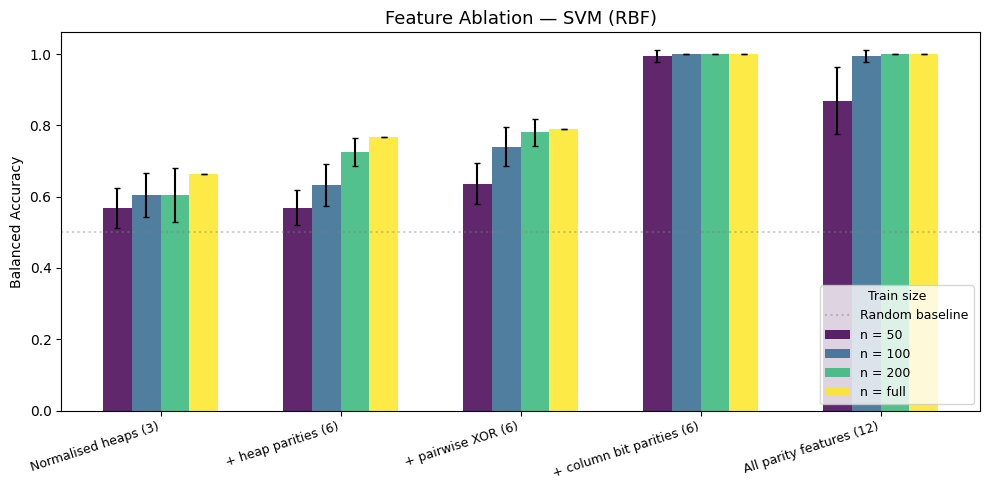

In [31]:
abl_df = ablation_sweep.to_dataframe()

size_labels = {50: "50", 100: "100", 200: "200", 357: "full"}
train_sizes = list(size_labels.keys())
n_fs = len(ABLATION_FEATURE_SETS)
n_sizes = len(train_sizes)
bar_width = 0.16
fs_offsets = np.arange(n_fs)

fig, ax = plt.subplots(figsize=(10, 5))

for j, tsz in enumerate(train_sizes):
    sub = abl_df[abl_df["train_size"] == tsz]
    means = sub.groupby("feature_set")["balanced_accuracy"].mean()
    stds = sub.groupby("feature_set")["balanced_accuracy"].std()
    vals = [means.get(fs, np.nan) for fs in ABLATION_FEATURE_SETS]
    errs = [stds.get(fs, 0) for fs in ABLATION_FEATURE_SETS]
    x = fs_offsets + (j - (n_sizes - 1) / 2) * bar_width
    ax.bar(x, vals, bar_width, yerr=errs, capsize=2,
           label=f"n = {size_labels[tsz]}", alpha=0.85,
           color=plt.cm.viridis(j / (n_sizes - 1)))

ax.set_xticks(fs_offsets)
ax.set_xticklabels(
    [FEATURE_SET_DESCRIPTIONS[fs] for fs in ABLATION_FEATURE_SETS],
    rotation=18, ha="right", fontsize=9,
)
ax.set_ylabel("Balanced Accuracy")
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.4, label="Random baseline")
ax.legend(title="Train size", fontsize=9, title_fontsize=9, loc="lower right")
ax.set_title("Feature Ablation — SVM (RBF)", fontsize=13)
plt.tight_layout()
plt.show()

### 3.9 Quantum-inspired kernel alignment

To fairly compare classical and quantum approaches, we test a classical SVM whose kernel **mimics the quantum angle-encoding feature map**. The angle encoding maps normalised heap size $x_i = h_i / M$ to a rotation $R_Y(x_i \pi)$ on one qubit. For a product-state encoding (no entanglement), the quantum kernel is the squared state overlap:

$$k(\mathbf{x}, \mathbf{x}') = \prod_{i=1}^{k} \cos^2\!\left(\frac{(x_i - x'_i)\,\pi}{2}\right)$$

Each factor $(1 + \cos(\Delta x_i \cdot \pi))/2$ is a valid positive semi-definite kernel, and the product of PSD kernels is PSD (Schur product theorem), so $k$ is a legitimate kernel for SVC.

This **kernel-aligned SVM** uses the same similarity structure as the quantum circuit would see — the question is whether that structure *by itself* is useful for Nim, independent of quantum hardware. It operates on raw (normalised) features only.

In [32]:
from qml_project.baselines import angle_encoding_kernel

kernel_sweep = run_classical_sweep(
    iid.X_train, iid.y_train,
    iid.X_test, iid.y_test,
    model_names=["SVM (Angle Kernel)"],
    feature_sets=["raw"],
    symmetry_variants=["none", "augmented"],
    train_sizes=[50, 100, 200, "full"],
    seeds=list(range(10)),
    M=7,
    regime="iid",
    compute_win_rate=False,
    mlflow_experiment="classical-kernel-aligned-iid",
    verbose=True,
)

kernel_summary = kernel_sweep.summary()
kernel_display = kernel_summary[[
    "model", "symmetry", "train_size",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "mcc_std",
]].copy()
for col in kernel_display.columns[3:]:
    kernel_display[col] = kernel_display[col].round(3)
print("Kernel-aligned SVM (angle encoding kernel) on raw features:")
display(kernel_display)

  [20/80] runs complete
  [40/80] runs complete
  [60/80] runs complete
  [80/80] runs complete
  Sweep complete: 80 runs.
Kernel-aligned SVM (angle encoding kernel) on raw features:


,model,symmetry,train_size,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,win_rate_mean,win_rate_std
0,SVM (Angle Kernel),augmented,50,0.617,0.068,0.163,0.091,0.519,0.042
1,SVM (Angle Kernel),augmented,100,0.640,0.058,0.198,0.085,0.513,0.029
2,SVM (Angle Kernel),augmented,200,0.699,0.028,0.281,0.051,0.489,0.026
3,SVM (Angle Kernel),augmented,357,0.731,0.000,0.317,0.000,0.495,0.042
4,SVM (Angle Kernel),none,50,0.566,0.059,0.100,0.092,0.482,0.056
5,SVM (Angle Kernel),none,100,0.573,0.060,0.115,0.093,0.502,0.080
6,SVM (Angle Kernel),none,200,0.583,0.058,0.117,0.081,0.508,0.066
7,SVM (Angle Kernel),none,357,0.676,0.000,0.237,0.000,0.499,0.023


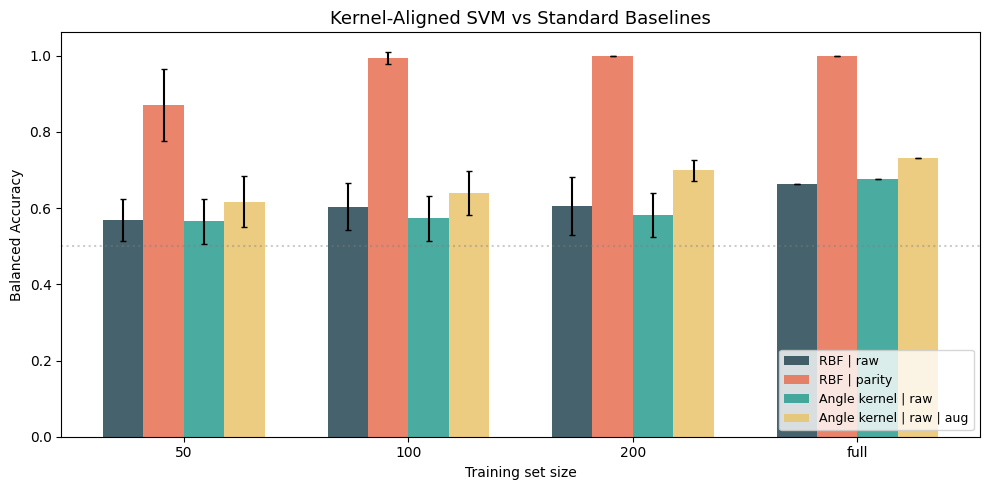

In [37]:
combined_df = pd.concat([
    iid_sweep.to_dataframe(),
    kernel_sweep.to_dataframe(),
], ignore_index=True)

configs_compare = [
    ("SVM (RBF)", "raw", "none", "RBF | raw"),
    ("SVM (RBF)", "parity", "none", "RBF | parity"),
    ("SVM (Angle Kernel)", "raw", "none", "Angle kernel | raw"),
    ("SVM (Angle Kernel)", "raw", "augmented", "Angle kernel | raw | aug"),
]
colors = ["#264653", "#e76f51", "#2a9d8f", "#e9c46a"]

size_labels = {50: "50", 100: "100", 200: "200", 357: "full"}
train_sizes_k = list(size_labels.keys())
n_configs = len(configs_compare)
n_sizes = len(train_sizes_k)
bar_width = 0.18
size_offsets = np.arange(n_sizes)

fig, ax = plt.subplots(figsize=(10, 5))

for j, ((model, fs, sym, lbl), col) in enumerate(zip(configs_compare, colors)):
    mask = (
        (combined_df["model"] == model)
        & (combined_df["feature_set"] == fs)
        & (combined_df["symmetry"] == sym)
    )
    sub = combined_df[mask]
    if sub.empty:
        continue
    means = sub.groupby("train_size")["balanced_accuracy"].mean()
    stds = sub.groupby("train_size")["balanced_accuracy"].std()
    vals = [means.get(tsz, np.nan) for tsz in train_sizes_k]
    errs = [stds.get(tsz, 0) for tsz in train_sizes_k]
    x = size_offsets + (j - (n_configs - 1) / 2) * bar_width
    ax.bar(x, vals, bar_width, yerr=errs, capsize=2,
           label=lbl, color=col, alpha=0.85)

ax.set_xticks(size_offsets)
ax.set_xticklabels([size_labels[s] for s in train_sizes_k])
ax.set_xlabel("Training set size")
ax.set_ylabel("Balanced Accuracy")
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.4)
ax.legend(fontsize=9, loc="lower right")
ax.set_title("Kernel-Aligned SVM vs Standard Baselines", fontsize=13)
plt.tight_layout()
plt.show()

In [38]:
kernel_ood_sweep = run_classical_sweep(
    ood.X_train, ood.y_train,
    ood.X_test, ood.y_test,
    model_names=["SVM (Angle Kernel)"],
    feature_sets=["raw"],
    symmetry_variants=["none", "augmented"],
    train_sizes=["full"],
    seeds=list(range(10)),
    M=7,
    regime="ood",
    compute_win_rate=False,
    mlflow_experiment="classical-kernel-aligned-ood",
    verbose=True,
)

kernel_ood_summary = kernel_ood_sweep.summary()
kernel_ood_display = kernel_ood_summary[[
    "model", "symmetry",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "mcc_mean", "mcc_std",
]].copy()
for col in kernel_ood_display.columns[2:]:
    kernel_ood_display[col] = kernel_ood_display[col].round(3)
print("OOD results — Kernel-aligned SVM (train M≤5, test M>5):")
display(kernel_ood_display)

  [20/20] runs complete
  Sweep complete: 20 runs.
OOD results — Kernel-aligned SVM (train M≤5, test M>5):


,model,symmetry,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std
0,SVM (Angle Kernel),augmented,0.574,0.0,0.121,0.0
1,SVM (Angle Kernel),none,0.574,0.0,0.121,0.0


### 3.10 Strengthened baselines: key findings

**Feature ablation:**
- The **column-wise bit parities** (`bit_parity`) are by far the most informative feature group, since they directly encode the individual bits of the Nim-sum. SVM (RBF) with bit parities alone achieves 0.995 balanced accuracy at just 50 training samples and perfect 1.000 at $\geq 100$.
- **Heap parities** ($h_i \bmod 2$) and **pairwise XOR** each improve over raw features but fall well short of the bit parities (~0.77 and ~0.79 at full training size, respectively). This confirms that Nim-sum classification requires access to the full bitwise parity structure, not just single-heap or pairwise information.
- The full `parity` set (all 12 features) does **not** improve over `bit_parity` alone — at 50 samples the full set (0.870) actually *underperforms* bit parities (0.995), likely because the extra feature dimensions add noise when data is scarce. At $\geq 200$ samples the two converge to perfect accuracy.

**Quantum-inspired angle kernel:**
- The **SVM (Angle Kernel)** operating on raw (normalised) features provides a direct classical analogue of the quantum angle-encoding feature map. Without augmentation it reaches ~0.68 balanced accuracy at full training size — comparable to RBF (~0.66). With $S_3$ augmentation it improves to ~0.73, though this gain (~0.05) is roughly half the RBF kernel's augmentation boost (~0.12), suggesting the cosine-product kernel structure benefits less from symmetry enrichment.
- OOD balanced accuracy for the angle kernel (0.574) slightly exceeds RBF on raw features (0.538), but both remain well below chance-level usefulness, indicating that neither kernel structure inherently improves generalisation to unseen board sizes.
- This kernel-aligned SVM sets a fair "structural" baseline: if the quantum kernel SVM (§5.4) or VQC does not exceed this classical analogue, the quantum advantage claim is weakened.

**Implication for QML:** The feature ablation shows that the *right features* make the problem trivially solvable. The question for QML is whether the quantum feature map can implicitly discover equivalent structure (particularly the bitwise XOR) without explicit feature engineering — and whether it can do so more sample-efficiently than classical models on raw features.

### 3.11 Why Nim is a relevant testbed for QML

The classical results above reveal a sharp structural divide in the Nim classification problem that makes it well-suited for investigating quantum machine learning.

**The Nim-sum boundary is an XOR function.** A position $(h_1, h_2, h_3)$ is losing if and only if $h_1 \oplus h_2 \oplus h_3 = 0$, where $\oplus$ denotes bitwise XOR. This decision boundary is a *parity function* over the binary representations of the heap sizes. Parity functions are a classical hard case for many learning algorithms: they cannot be represented by any bounded-degree polynomial over the raw inputs, and kernel methods with smooth kernels (such as RBF) must approximate a highly non-smooth boundary. Our results confirm this. SVM (RBF) on raw heap sizes plateaus at ~0.66 balanced accuracy even with the full 357-sample training set, and Logistic Regression does no better than chance (~0.47). The decision boundary is invisible to models that rely on smooth interpolation of continuous features.

**Parity features make the problem trivial.** When we supply the column-wise bit parities (the individual bits of the Nim-sum) as engineered features, the problem becomes linearly separable. SVM and Logistic Regression both achieve perfect classification with as few as 50 training samples. The feature ablation (§3.8) isolates this effect precisely: bit parities alone saturate performance, while heap-level parities and pairwise XOR each capture only partial structure. This gap between "raw features, hard" and "right features, trivial" is the crux of the QML question.

**The sample efficiency hypothesis.** Quantum feature maps based on rotation gates and entangling operations can, by construction, encode phase relationships that correspond to parity functions. Angle encoding maps each heap size to a qubit rotation $R_Y(h_i \pi / M)$, placing the input into a Hilbert space where the inner product between states depends on trigonometric functions of the differences. Binary encoding goes further: representing each heap in a 3-bit binary string on 9 qubits and entangling corresponding bit positions across heaps mirrors the bitwise XOR of the Nim-sum directly. If the quantum feature map implicitly captures the XOR structure that classical models on raw features cannot access, the VQC should learn faster from fewer examples. The central experiment (§8) tests this: we train classical and quantum pipelines at each training-set size and compare balanced accuracy and win rate as a function of sample count.

**What QML needs to beat.** The classical baselines establish three reference points:

| Baseline | Raw features | Parity features |
|---|---|---|
| SVM (RBF), full training set | ~0.66 bal. acc., ~0.48 win rate | 1.000 bal. acc., 1.000 win rate |
| SVM (Angle Kernel), full training set | ~0.68 bal. acc. | — |
| Best classical at 50 samples | ~0.59 bal. acc. (SVM-RBF) | ~0.99 bal. acc. (SVM-RBF with bit parities) |

The angle-encoding kernel SVM (~0.68 balanced accuracy on raw features) is the most direct structural baseline for the quantum pipeline: it uses the same cosine-product similarity that the 3-qubit quantum feature map induces, computed classically. If the VQC fails to exceed this, the variational ansatz adds no value beyond what the feature map already provides. Conversely, if the VQC approaches the parity-feature ceiling (1.000) on raw inputs, it would indicate that the quantum circuit has learned an implicit representation of the Nim-sum XOR.

**OOD as a stronger test.** Beyond sample efficiency, the OOD regime (train on $M \leq 5$, test on $M = 6, 7$) provides a complementary signal. Classical models with parity features generalise perfectly OOD because the bit-parity features are algebraically valid at any $M$. Classical models on raw features collapse to near-chance OOD (~0.54 balanced accuracy). If the quantum feature map genuinely encodes XOR structure, QML on raw features should generalise better than its classical counterpart on raw features. This would be evidence that the model has learned the *rule* rather than memorised the training distribution.

**Symmetry as inductive bias.** The $S_3$ heap permutation symmetry provides a third axis for the comparison. Data augmentation helps Random Forest dramatically on raw features (0.48 $\to$ 1.00 balanced accuracy at full training), showing that the symmetry information is highly valuable. Whether canonical ordering or equivariant circuit design can deliver similar gains for QML, especially at small training sizes, is a natural question for the QML pipeline (§5).

## 4. QML Input Transformation

*Supports: Input Transformation & Data Prep (10%)*

Three encoding schemes: (1) Angle encoding on 3 qubits ($\theta_i = h_i \cdot \pi / M$), (2) Binary encoding on 9 qubits (3 bits per heap, entanglement aligned to Nim-sum XOR bit positions), (3) IQP/parity feature map emphasising XOR structure. Fixed normalisation by $M_{\max} = 7$ for OOD consistency. Encoding comparison on accuracy, sample efficiency, and circuit depth.

## 5. QML Model Design

*Supports: QML Model Design & Optimisation (30%)*

At least two distinct VQC ansatze per encoding with different hypotheses about Nim-sum structure. Quantum kernel SVM as a bridge pipeline. Measurement and post-processing strategy (observable, decision rule, loss function). Expressibility (KL divergence from Haar-random), entangling capability (Meyer-Wallach measure), and barren plateau diagnosis (gradient variance vs depth).

## 6. Training and Optimisation

*Supports: QML Model Design & Optimisation (30%)*

COBYLA optimisation (SPSA fallback) with 10+ seeds per configuration. MLflow experiment tracking. Sample-efficiency sweep (train on each subset size: 50, 100, 200, 500, full). Symmetry controlled experiment (raw vs augmented vs canonical vs equivariant). Loss function exploration.

## 7. Experimental Design

*Supports: Experimental Design (20%)*

Noise sweep (depolarising rates 0.001–0.05 + backend-specific noise model from IBM calibration data). Error mitigation: measurement error mitigation (readout correction matrix) and zero-noise extrapolation (ZNE). Shot budget analysis (8192 down to 512 shots). Transfer learning experiment (train $M = 3$, fine-tune $M = 5$, test $M = 7$). Device pipeline design and budget.

## 8. Simulated QML Results

Sample-efficiency curves (accuracy and win rate vs training set size for all pipelines, mean $\pm$ std over 10+ seeds with 95% bootstrap CI). OOD generalisation results (IID vs OOD accuracy comparison). Symmetry experiment results. Quantum kernel matrix visualisations.

## 9. Quantum Device Inference

*Supports: Experimental Design (20%); Evaluation & Discussion (15%)*

IBM Quantum free tier, inference-only (no training on device). Budget-conscious test set (30–50 stratified states, 1024 shots). Measurement error mitigation (readout correction matrix) applied to device results. Three-way comparison: raw device vs readout-corrected device vs simulated noisy results.

## 10. Four-Way Comparison

*Supports: Evaluation Methodology and Discussion of Findings (15%)*

Compare all pipelines (classical, quantum kernel SVM, simulated VQC, device VQC) on: balanced accuracy, MCC, win rate, sample efficiency (central finding), OOD generalisation (secondary), cost (wall-clock time, shots, credits), speed (per-sample latency), interpretability. Formal statistical tests: paired Wilcoxon signed-rank with Bonferroni correction, Cohen's d effect sizes, power-law learning curve fits ($\text{accuracy} \sim a - b \cdot n^{-c}$), 95% bootstrap confidence intervals.

## 11. Discussion

### 11.1 Related Work

QML sample efficiency (Huang et al. 2021), QML for combinatorial games, quantum kernel theory (Schuld & Killoran [18]), noise resilience and shallow circuits ([5], [7], [20]), QML vs classical benchmarks ([8], [10]).

### 11.2 Limitations

Small state space (511 states), deterministic game, limited qubits (3–9), optimiser convergence, shot noise, class imbalance at small sample sizes, no real quantum advantage claim.

### 11.3 Adversarial and Hard-Case Analysis

Confusion geography heatmaps, failure clustering by Nim-sum magnitude, disagreement analysis between pipelines.

## 12. References

- [5] Cincio, L. et al. — Variational hybrid algorithms.
- [7] Fontana, E. et al. — Noise resilience.
- [8] Houssein, E. A. et al. — QML state-of-the-art survey.
- [10] Khan, T. M. & Robles-Kelly, A. — Quantum vs classical ML.
- [13] McClean, J. R. et al. — Barren plateaus in QNNs.
- [18] Schuld, M. & Killoran, N. — Quantum feature spaces.
- [20] Selig, P. et al. — Noisy shallow circuits, angle mapping.
- Huang, H.-Y. et al. (2021) — Power of data in quantum machine learning.
- Sim, S. et al. (2019) — Expressibility and entangling capability of parameterized quantum circuits.